**Important**

In order to access the data, you must first manually add a shortcut of the shared folder 'Group 10 Project' through the google drive interface.

First go to your shared with me google drive view, find the folder, click on the elipsis on the righthand side, hover over the organize banner, and then click on the option that says 'Add shortcut'



In [ ]:
#install packages
!pip install mne numpy matplotlib

In [ ]:
#this is going to look differently for Hudson, since he is the owner of the folder, and thus the content will not appear in the 'Shared Drive"

#click through the google warnings about connecting your google account


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/My Drive/Group 10 Project/data/eegmmidb/')[:5])

DATA_PATH = "/content/drive/My Drive/Group 10 Project/data/eegmmidb/"

Mounted at /content/drive
['64_channel_sharbrough-old.png', 'SHA256SUMS.txt', 'ANNOTATORS', 'RECORDS', '64_channel_sharbrough.pdf']


In [ ]:
#checking and making sure that all of the information is in there.
from pathlib import Path
import pandas as pd
import numpy as np

data_root = Path(DATA_PATH)

# List subjects
subjects = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith("S")])

print("Total subjects:", len(subjects))
print("Example subjects:", [s.name for s in subjects[:10]])
print()

# Inspect first few subjects
for subj in subjects[:5]:
    edf_files = sorted(subj.glob("*.edf"))
    event_files = sorted(subj.glob("*.edf.event"))

    print(subj.name)
    print("  EDF files:", len(edf_files))
    print("  EVENT files:", len(event_files))
    print("  Sample runs:", [f.name for f in edf_files[:3]])
    print()

# Dataset-level structure files
print("RECORDS present:", (data_root / "RECORDS").exists())
print("ANNOTATORS present:", (data_root / "ANNOTATORS").exists())

Total subjects: 109
Example subjects: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']

S001
  EDF files: 14
  EVENT files: 14
  Sample runs: ['S001R01.edf', 'S001R02.edf', 'S001R03.edf']

S002
  EDF files: 14
  EVENT files: 14
  Sample runs: ['S002R01.edf', 'S002R02.edf', 'S002R03.edf']

S003
  EDF files: 14
  EVENT files: 14
  Sample runs: ['S003R01.edf', 'S003R02.edf', 'S003R03.edf']

S004
  EDF files: 14
  EVENT files: 14
  Sample runs: ['S004R01.edf', 'S004R02.edf', 'S004R03.edf']

S005
  EDF files: 14
  EVENT files: 14
  Sample runs: ['S005R01.edf', 'S005R02.edf', 'S005R03.edf']

RECORDS present: True
ANNOTATORS present: True


verifies file organization

maps run numbers to task conditions

loads one EDF safely with MNE

extracts annotations

prepares subject/run metadata for later PCA

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

data_root = Path(DATA_PATH)

# collecting all of the subjects together.
subjects = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith("S")])

print(f"Total subjects found: {len(subjects)}")
print("First 10 subjects:", [s.name for s in subjects[:10]])

# this is the condition mapping
run_map = {
    1: "baseline_eyes_open",
    2: "baseline_eyes_closed",
    3: "task1_real_lr",
    4: "task2_imagery_lr",
    5: "task3_real_bf",
    6: "task4_imagery_bf",
    7: "task1_real_lr",
    8: "task2_imagery_lr",
    9: "task3_real_bf",
    10: "task4_imagery_bf",
    11: "task1_real_lr",
    12: "task2_imagery_lr",
    13: "task3_real_bf",
    14: "task4_imagery_bf",
}

# building the metadata table!
rows = []

for subj in subjects:
    edf_files = sorted(subj.glob("*.edf"))
    for edf in edf_files:
        stem = edf.stem
        # some sort of expected format like S001R03
        run_num = int(stem.split("R")[-1])
        event_file = edf.with_suffix(".edf.event")

        rows.append({
            "subject": subj.name,
            "run": run_num,
            "condition": run_map.get(run_num, "unknown"),
            "edf_path": str(edf),
            "event_path": str(event_file),
            "event_exists": event_file.exists(),
        })

meta_df = pd.DataFrame(rows).sort_values(["subject", "run"]).reset_index(drop=True)

print("Metadata shape:", meta_df.shape)
display(meta_df.head(20))

print("\nCondition counts:")
display(meta_df["condition"].value_counts().sort_index())

print("\nMissing event files:", (~meta_df["event_exists"]).sum())

Total subjects found: 109
First 10 subjects: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']
Metadata shape: (1526, 6)


,subject,run,condition,edf_path,event_path,event_exists
0,S001,1,baseline_eyes_open,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
1,S001,2,baseline_eyes_closed,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
2,S001,3,task1_real_lr,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
3,S001,4,task2_imagery_lr,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
4,S001,5,task3_real_bf,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
5,S001,6,task4_imagery_bf,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
6,S001,7,task1_real_lr,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
7,S001,8,task2_imagery_lr,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
8,S001,9,task3_real_bf,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True
9,S001,10,task4_imagery_bf,/content/drive/My Drive/Group 10 Project/data/...,/content/drive/My Drive/Group 10 Project/data/...,True



Condition counts:


,count
condition,
baseline_eyes_closed,109
baseline_eyes_open,109
task1_real_lr,327
task2_imagery_lr,327
task3_real_bf,327
task4_imagery_bf,327



Missing event files: 0


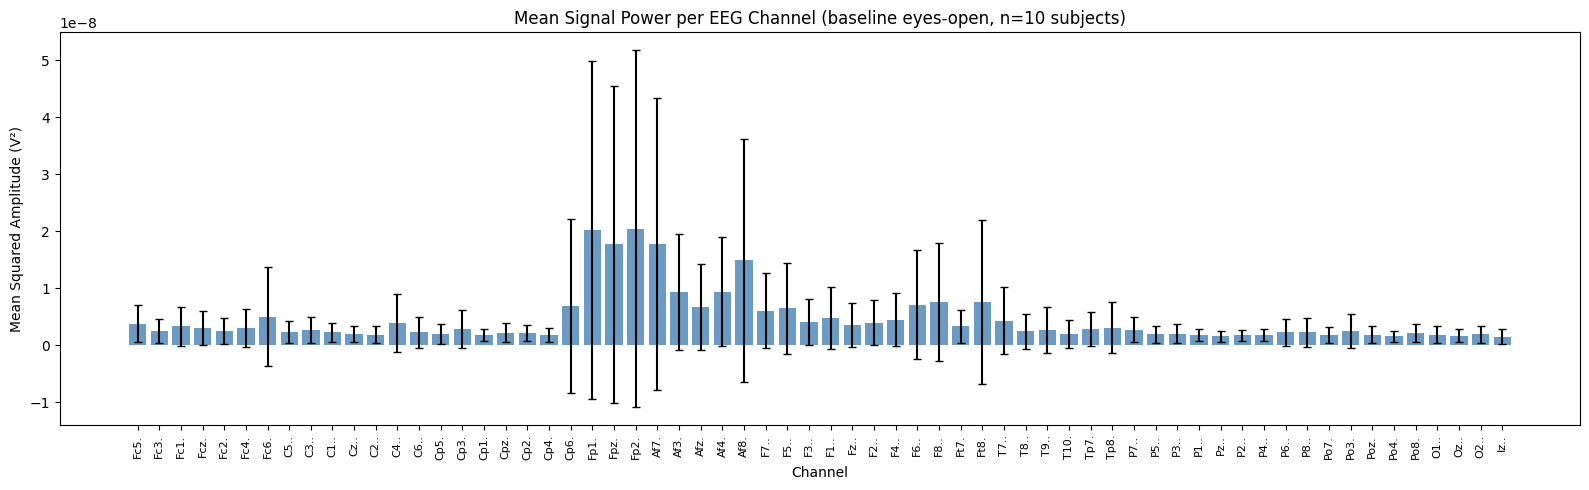

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load a few subjects' resting-state (eyes open) runs
N_SUBJECTS = 10
baseline_files = meta_df[meta_df["condition"] == "baseline_eyes_open"]["edf_path"].head(N_SUBJECTS).tolist()

channel_powers = []

for path in baseline_files:
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    data = raw.get_data()  # shape: (n_channels, n_times)
    power = np.mean(data**2, axis=1)  # RMS power per channel
    channel_powers.append(power)

channel_powers = np.array(channel_powers)  # (n_subjects, n_channels)
mean_power = np.mean(channel_powers, axis=0)
std_power = np.std(channel_powers, axis=0)
channel_names = raw.ch_names

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(channel_names))
ax.bar(x, mean_power, yerr=std_power, capsize=3, color="steelblue", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=90, fontsize=8)
ax.set_title(f"Mean Signal Power per EEG Channel (baseline eyes-open, n={N_SUBJECTS} subjects)")
ax.set_ylabel("Mean Squared Amplitude (V²)")
ax.set_xlabel("Channel")
plt.tight_layout()
plt.show()